In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [3]:
env = gym.make(
    "FrozenLake-v1",
    map_name = "4x4",
    is_slippery = True
)

In [4]:
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)

Observation space: Discrete(16)
Action space: Discrete(4)
Number of states: 16
Number of actions: 4


In [8]:
state, info = env.reset(seed=42)

print("Initial state:", state)
print("Info", info)

Initial state: 0
Info {'prob': 1}


In [9]:
action = env.action_space.sample()

print("Selected action: ", action)

Selected action:  1


In [10]:
next_state, reward, terminated, truncated, info = env.step(action)

In [11]:
print("Next state:", next_state)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
print("Info:", info)

Next state: 4
Reward: 0
Terminated: False
Truncated: False
Info: {'prob': 0.3333333333333333}


In [12]:
num_episodes = 10000

successes = 0
episode_lengths = []

rng = np.random.default_rng(42)

state, info = env.reset(seed = 42)

for episode in range(num_episodes):

    if episode > 0:
        state, info = env.reset()

    done = False
    steps = 0

    while not done:

        action = rng.integers(env.action_space.n)

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        
        state = next_state
        steps += 1

    successes += reward
    episode_lengths.append(steps)
    

In [13]:
success_rate = successes / num_episodes

print(f"Successful episodes: {int(successes)} / {num_episodes}")
print(f"Success rate: {100 * success_rate:.2f}%")
print(f"Average episode length: {np.mean(episode_lengths):.2f} steps")

Successful episodes: 164 / 10000
Success rate: 1.64%
Average episode length: 7.70 steps


In [14]:
# Q-table
Q = np.zeros(
    (env.observation_space.n,
     env.action_space.n)
)

# Hyperparameters
alpha = 0.8 
gamma = 0.95

epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.9995

num_episodes = 20000

# Random number generator 
rng = np.random.default_rng(42)

# Store the reward from every episode
training_rewards = []

for episode in range(num_episodes):

    state, info = env.reset()

    terminated = False
    truncated = False

    episode_reward = 0

    while not (terminated or truncated):

        # =========================================
        # 1. Choose action using epsilon-greedy
        # =========================================

        if rng.random() < epsilon:
            
            # Exploration
            action = rng.integers(
                env.action_space.n
            )

        else:

            # Exploitation
            max_actions = np.flatnonzero(
                Q[state] == np.max(Q[state])
            )

            action = rng.choice(max_actions)

        # =========================================
        # 2. Perform action
        # =========================================


        next_state, reward, terminated, truncated, info = \
            env.step(action)
        

        # =========================================
        # 3. Calculate Q-learning target
        # =========================================

        if terminated:

            target = reward

        else:

            target = (
                reward
                + gamma * np.max(Q[next_state])
            )

        # =========================================
        # 4. Update Q(s,a)
        # =========================================

        Q[state, action] += (
            alpha
            * (target - Q[state, action])
        )

        # =========================================
        # 5. Move to next state
        # =========================================

        state = next_state
        episode_reward += reward

    # Store whether this episode succeeded
    training_rewards.append(episode_reward)

    # ========================================= 
    # 6. Reduce exploration
    # =========================================

    epsilon = max(
        epsilon_min,
        epsilon*epsilon_decay
    )

In [15]:
np.set_printoptions(
    precision=3,
    suppress=True
)

print(Q)

[[0.172 0.053 0.05  0.029]
 [0.003 0.002 0.001 0.017]
 [0.004 0.01  0.007 0.006]
 [0.    0.002 0.001 0.069]
 [0.167 0.022 0.004 0.022]
 [0.    0.    0.    0.   ]
 [0.104 0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.012 0.    0.071 0.257]
 [0.004 0.457 0.022 0.258]
 [0.501 0.012 0.007 0.012]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.097 0.124 0.37  0.033]
 [0.616 0.923 0.21  0.202]
 [0.    0.    0.    0.   ]]


In [16]:
policy = np.argmax(Q, axis=1)

print(policy.reshape(4, 4))

[[0 3 1 3]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]


In [17]:
action_symbols = np.array([
    "←", "↓", "→", "↑"
])

policy_symbols = action_symbols[policy]

print(policy_symbols.reshape(4, 4))

[['←' '↑' '↓' '↑']
 ['←' '←' '←' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '↓' '←']]


In [18]:
num_test_episodes = 10000

test_successes = 0
test_episode_lengths = []

for episode in range(num_test_episodes):

    state, info = env.reset()

    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated):

        # Pure exploitation
        max_actions = np.flatnonzero(
            Q[state] == np.max(Q[state])
        )

        action = rng.choice(max_actions)

        next_state, reward, terminated, truncated, info = \
            env.step(action)
        
        state = next_state
        steps += 1

    test_successes += reward
    test_episode_lengths.append(steps)

In [ ]:
success_rate = successes / num_test_episodes

print(
    f"Successful episodes: "
    f"{int(successes)} / {num_test_episodes}"
)

print(
    f"Success rate: "
    f"{100 * success_rate:.2f}%"
)

print(
    f"Average episode length: "
    f"{np.mean(episode_lengths):.2f} steps"
)

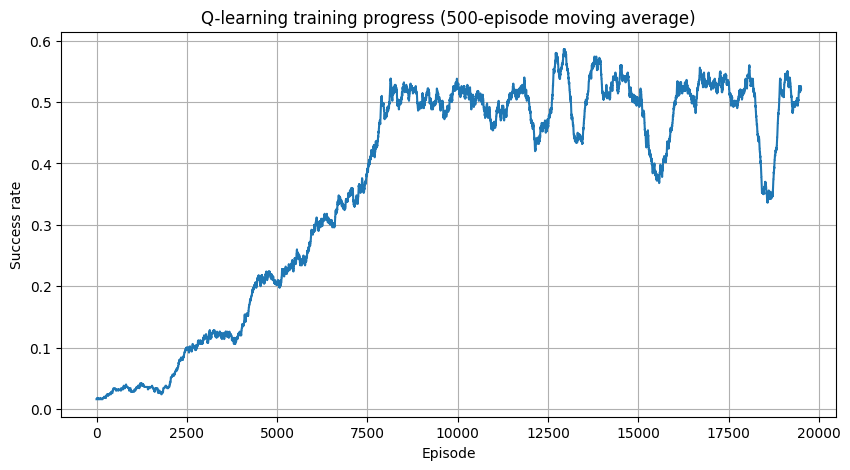

In [19]:
window = 500

moving_success_rate = np.convolve(
    training_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(moving_success_rate)

plt.xlabel("Episode")
plt.ylabel("Success rate")
plt.title(
    f"Q-learning training progress "
    f"({window}-episode moving average)"
)

plt.grid()

plt.show()

In [31]:
visual_env = gym.make(
    "FrozenLake-v1",
    map_name="4x4",
    is_slippery=True,
    render_mode="human"
)

In [26]:
state, info = visual_env.reset()

terminated = False
truncated = False

while not (terminated or truncated):

    # Find the actions with the highest Q-value
    max_actions = np.flatnonzero(
        Q[state] == np.max(Q[state])
    )

    # Random tie-breaking only
    action = rng.choice(max_actions)

    # Execute learned action
    next_state, reward, terminated, truncated, info = \
        visual_env.step(action)

    state = next_state

visual_env.close()

In [32]:
num_visual_episodes = 5

for episode in range(num_visual_episodes):

    state, info = visual_env.reset()

    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated):

        max_actions = np.flatnonzero(
            Q[state] == np.max(Q[state])
        )

        action = rng.choice(max_actions)

        state, reward, terminated, truncated, info = \
            visual_env.step(action)

        steps += 1

    print(
        f"Episode {episode + 1}: "
        f"{'SUCCESS' if reward == 1 else 'FAILURE'}, "
        f"{steps} steps"
    )

visual_env.close()

Episode 1: SUCCESS, 23 steps
Episode 2: FAILURE, 100 steps
Episode 3: SUCCESS, 66 steps
Episode 4: SUCCESS, 52 steps
Episode 5: SUCCESS, 37 steps
